# Bonus Challenge 4 — Processing Streaming Data (Pub/Sub → BigQuery → GeoViz)


## 0. Configuration

In [1]:
# Outside a managed BQ notebook, authenticate first:
# from google.colab import auth; auth.authenticate_user()

from google.cloud import bigquery, pubsub_v1

# --- Pub/Sub source (given by the challenge) ---
PUBSUB_PROJECT = "paul-leroy"
TOPIC_NAME     = "flight-transponder"

# --- Your own project for BigQuery storage ---
BQ_PROJECT = None   # e.g. "qwiklabs-gcp-..."; None => environment default
DATASET    = "transponder_data_colab"
TABLE      = "flight_transponder_msgs"
LOCATION   = "US"

bq = bigquery.Client(project=BQ_PROJECT) if BQ_PROJECT else bigquery.Client()
BQ_PROJECT = bq.project
print("BigQuery project:", BQ_PROJECT)

TABLE_ID = f"{BQ_PROJECT}.{DATASET}.{TABLE}"
print("Target table:", TABLE_ID)


BigQuery project: qwiklabs-gcp-01-9ed82c2a1f67
Target table: qwiklabs-gcp-01-9ed82c2a1f67.transponder_data_colab.flight_transponder_msgs


## 1. Create the dataset and table


In [12]:
    from google.cloud import bigquery

    bq.create_dataset(bigquery.Dataset(f"{BQ_PROJECT}.{DATASET}"), exists_ok=True)
    print("Dataset ready:", DATASET)

    schema = [
        bigquery.SchemaField("MT",   "STRING",  mode="NULLABLE", description="Message type (MSG, SEL, ID, AIR, STA, CLK)"),
        bigquery.SchemaField("TT",   "INT64",   mode="NULLABLE", description="Transmission type 1-8"),
        bigquery.SchemaField("SID",  "STRING",  mode="NULLABLE", description="Database Session record number"),
        bigquery.SchemaField("AID",  "STRING",  mode="NULLABLE", description="Database Aircraft record number"),
        bigquery.SchemaField("Hex",  "STRING",  mode="NULLABLE", description="Aircraft Mode S hexadecimal code"),
        bigquery.SchemaField("FID",  "STRING",  mode="NULLABLE", description="Database Flight record number"),
        bigquery.SchemaField("DMG",  "DATE",    mode="NULLABLE", description="Date message generated"),
        bigquery.SchemaField("TMG",  "TIME",    mode="NULLABLE", description="Time message generated"),
        bigquery.SchemaField("DML",  "DATE",    mode="NULLABLE", description="Date message logged"),
        bigquery.SchemaField("TML",  "TIME",    mode="NULLABLE", description="Time message logged"),
        bigquery.SchemaField("CS",   "STRING",  mode="NULLABLE", description="Callsign (flight number or registration)"),
        bigquery.SchemaField("Alt",  "INT64",   mode="NULLABLE", description="Mode C altitude (Flight Level)"),
        bigquery.SchemaField("GS",   "INT64",   mode="NULLABLE", description="Ground Speed"),
        bigquery.SchemaField("Trk",  "INT64",   mode="NULLABLE", description="Track"),
        bigquery.SchemaField("Lat",  "FLOAT64", mode="NULLABLE", description="Latitude (N/E positive, S/W negative)"),
        bigquery.SchemaField("Lng",  "FLOAT64", mode="NULLABLE", description="Longitude (N/E positive, S/W negative)"),
        bigquery.SchemaField("VR",   "INT64",   mode="NULLABLE", description="Vertical Rate"),
        bigquery.SchemaField("Sq",   "STRING",  mode="NULLABLE", description="Assigned Mode A squawk code"),
        bigquery.SchemaField("Alrt", "INT64",   mode="NULLABLE", description="Flag: squawk has changed"),
        bigquery.SchemaField("Emer", "INT64",   mode="NULLABLE", description="Flag: emergency code set"),
        bigquery.SchemaField("SPI",  "INT64",   mode="NULLABLE", description="Flag: transponder Ident activated"),
        bigquery.SchemaField("Gnd",  "INT64",   mode="NULLABLE", description="Flag: ground squat switch active"),
    ]

    table = bigquery.Table(TABLE_ID, schema=schema)
    bq.create_table(table, exists_ok=True)
    print("Table ready:", TABLE_ID, "with", len(schema), "fields")


BigQuery project: qwiklabs-gcp-01-9ed82c2a1f67
Target table: qwiklabs-gcp-01-9ed82c2a1f67.transponder_data_colab.flight_transponder_msgs


## 2. Parser: SBS CSV line → BigQuery row


In [5]:
FIELD_NAMES = [f.name for f in schema]
INT_FIELDS   = {"TT","Alt","GS","Trk","VR","Alrt","Emer","SPI","Gnd"}
FLOAT_FIELDS = {"Lat","Lng"}
DATE_FIELDS  = {"DMG","DML"}   # YYYY/MM/DD -> YYYY-MM-DD

def parse_sbs(line):
    """Parse one SBS CSV line into a dict keyed by schema field names."""
    parts = line.strip().split(",")
    # Pad/truncate defensively to exactly 22 fields
    parts = (parts + [""] * 22)[:22]

    row = {}
    for name, raw in zip(FIELD_NAMES, parts):
        val = raw.strip()
        if val == "":
            row[name] = None
            continue
        try:
            if name in INT_FIELDS:
                row[name] = int(val)
            elif name in FLOAT_FIELDS:
                row[name] = float(val)
            elif name in DATE_FIELDS:
                row[name] = val.replace("/", "-")   # 2025/04/15 -> 2025-04-15
            else:
                row[name] = val                      # STRING and TIME pass through
        except ValueError:
            row[name] = None
    return row

# Quick test on the sample messages from the challenge
samples = [
    "MSG,3,1,1,ACAE7C,1,2025/04/15,00:43:07.127,2025/04/15,00:43:07.171,,2350,,,33.59715,-117.64749,,,0,,0,0",
    "MSG,4,1,1,ACAE7C,1,2025/04/15,00:43:07.127,2025/04/15,00:43:07.172,,,102,271,,,-448,,,,,0",
    "MSG,4,1,1,A27614,1,2025/04/15,00:43:07.150,2025/04/15,00:43:07.176,,,438,50,,,64,,,,,0",
]
for s in samples:
    print(parse_sbs(s))


{'MT': 'MSG', 'TT': 3, 'SID': '1', 'AID': '1', 'Hex': 'ACAE7C', 'FID': '1', 'DMG': '2025-04-15', 'TMG': '00:43:07.127', 'DML': '2025-04-15', 'TML': '00:43:07.171', 'CS': None, 'Alt': 2350, 'GS': None, 'Trk': None, 'Lat': 33.59715, 'Lng': -117.64749, 'VR': None, 'Sq': None, 'Alrt': 0, 'Emer': None, 'SPI': 0, 'Gnd': 0}
{'MT': 'MSG', 'TT': 4, 'SID': '1', 'AID': '1', 'Hex': 'ACAE7C', 'FID': '1', 'DMG': '2025-04-15', 'TMG': '00:43:07.127', 'DML': '2025-04-15', 'TML': '00:43:07.172', 'CS': None, 'Alt': None, 'GS': 102, 'Trk': 271, 'Lat': None, 'Lng': None, 'VR': -448, 'Sq': None, 'Alrt': None, 'Emer': None, 'SPI': None, 'Gnd': 0}
{'MT': 'MSG', 'TT': 4, 'SID': '1', 'AID': '1', 'Hex': 'A27614', 'FID': '1', 'DMG': '2025-04-15', 'TMG': '00:43:07.150', 'DML': '2025-04-15', 'TML': '00:43:07.176', 'CS': None, 'Alt': None, 'GS': 438, 'Trk': 50, 'Lat': None, 'Lng': None, 'VR': 64, 'Sq': None, 'Alrt': None, 'Emer': None, 'SPI': None, 'Gnd': 0}


## 3. Pull subscriber: collect from Pub/Sub and stream into BigQuery


In [6]:
import uuid, time

subscriber = pubsub_v1.SubscriberClient()
topic_path = subscriber.topic_path(PUBSUB_PROJECT, TOPIC_NAME)

# Create a subscription in YOUR project against the shared topic.
sub_id   = f"flight-sub-{uuid.uuid4().hex[:8]}"
sub_path = subscriber.subscription_path(BQ_PROJECT, sub_id)

try:
    subscriber.create_subscription(request={"name": sub_path, "topic": topic_path})
    print("Created subscription:", sub_path)
except Exception as e:
    print("Subscription create note:", e)


Created subscription: projects/qwiklabs-gcp-01-9ed82c2a1f67/subscriptions/flight-sub-f4856962


In [7]:
RUN_SECONDS = 180   # ~3 minutes; adjust as you like
BATCH       = 100

inserted = 0
errors   = 0
start    = time.time()
print(f"Collecting for {RUN_SECONDS}s ...")

while time.time() - start < RUN_SECONDS:
    resp = subscriber.pull(request={"subscription": sub_path, "max_messages": BATCH},
                           timeout=10)
    if not resp.received_messages:
        continue

    rows, ack_ids = [], []
    for rm in resp.received_messages:
        ack_ids.append(rm.ack_id)
        text = rm.message.data.decode("utf-8", errors="ignore")
        # A single Pub/Sub message may carry one or several CSV lines
        for line in text.splitlines():
            if line.strip():
                rows.append(parse_sbs(line))

    if rows:
        errs = bq.insert_rows_json(TABLE_ID, rows)
        if errs:
            errors += len(errs)
            print("Insert errors (sample):", errs[:2])
        else:
            inserted += len(rows)

    subscriber.acknowledge(request={"subscription": sub_path, "ack_ids": ack_ids})
    print(f"  ...{inserted} rows inserted so far", end="\r")

print(f"\nDone. Inserted ~{inserted} rows, {errors} insert errors.")


  ...13347 rows inserted so far
Done. Inserted ~13347 rows, 0 insert errors.


## 4. Count the records (Step 5)


In [8]:
bq.query(f"SELECT COUNT(*) AS record_count FROM `{TABLE_ID}`").to_dataframe()

,record_count
0,13347


## A quick look at what we collected

In [9]:
bq.query(f"""
SELECT MT, TT, Hex, CS, Alt, GS, Trk, Lat, Lng
FROM `{TABLE_ID}`
WHERE Lat IS NOT NULL AND Lng IS NOT NULL
LIMIT 15
""").to_dataframe()


,MT,TT,Hex,CS,Alt,GS,Trk,Lat,Lng
0,MSG,3,4BCDEA,None,38000,<NA>,<NA>,51.61162,0.05360
1,MSG,3,C02ECA,None,9025,<NA>,<NA>,51.76772,-0.70491
2,MSG,3,4CAD2B,None,21375,<NA>,<NA>,51.48375,-0.83359
3,MSG,3,406015,None,23800,<NA>,<NA>,50.56512,-1.71849
4,MSG,3,4076ED,None,27000,<NA>,<NA>,51.29105,-0.66267
5,MSG,3,408210,None,29000,<NA>,<NA>,51.61894,0.41911
6,MSG,3,49D283,None,26350,<NA>,<NA>,51.53064,-1.12313
7,MSG,3,AB9D9E,None,9650,<NA>,<NA>,51.45316,-0.85258
8,MSG,3,C079CE,None,5300,<NA>,<NA>,51.52052,-0.66638
9,MSG,3,4007F5,None,3225,<NA>,<NA>,51.44664,-0.57700


## 5. Location query for Geo Viz (Step 6)


In [10]:
GEO_QUERY = f"""
SELECT
  ST_GEOGPOINT(Lng, Lat) AS Location
FROM `{TABLE_ID}`
WHERE Lat IS NOT NULL
  AND Lng IS NOT NULL
"""
print(GEO_QUERY)

# Preview the points locally as a sanity check before visualizing
bq.query(f"""
SELECT Lat, Lng, Hex, CS
FROM `{TABLE_ID}`
WHERE Lat IS NOT NULL AND Lng IS NOT NULL
LIMIT 25
""").to_dataframe()



SELECT
  ST_GEOGPOINT(Lng, Lat) AS Location
FROM `qwiklabs-gcp-01-9ed82c2a1f67.transponder_data_colab.flight_transponder_msgs`
WHERE Lat IS NOT NULL
  AND Lng IS NOT NULL



,Lat,Lng,Hex,CS
0,51.61162,0.05360,4BCDEA,None
1,51.76772,-0.70491,C02ECA,None
2,51.48375,-0.83359,4CAD2B,None
3,50.56512,-1.71849,406015,None
4,51.29105,-0.66267,4076ED,None
5,51.61894,0.41911,408210,None
6,51.53064,-1.12313,49D283,None
7,51.45316,-0.85258,AB9D9E,None
8,51.52052,-0.66638,C079CE,None
9,51.44664,-0.57700,4007F5,None


## 6. Visualize in BigQuery Geo Viz (Step 7)


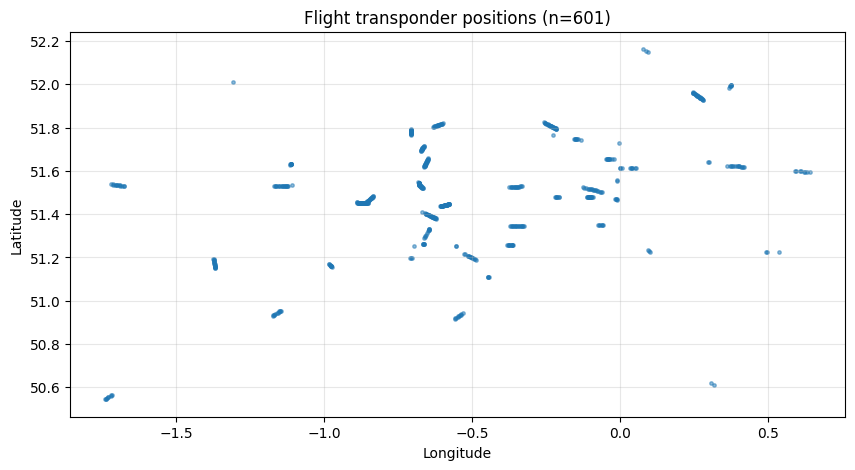

In [11]:
import matplotlib.pyplot as plt

pts = bq.query(f"""
SELECT Lng, Lat
FROM `{TABLE_ID}`
WHERE Lat IS NOT NULL AND Lng IS NOT NULL
""").to_dataframe()

plt.figure(figsize=(10,5))
plt.scatter(pts["Lng"], pts["Lat"], s=6, alpha=0.5)
plt.title(f"Flight transponder positions (n={len(pts)})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.show()
